In [ ]:
import os
results = os.listdir("./n_grams/")
results

['df_unigrams_ai_sorted.csv',
 'df_unigrams_human_sorted.csv',
 'df_bigrams_ai_sorted.csv',
 'df_bigrams_human_sorted.csv',
 'df_trigrams_ai_sorted.csv',
 'df_trigrams_human_sorted.csv',
 'df_unigrams_ai_sorted_no_sw.csv',
 'df_unigrams_human_sorted_no_sw.csv',
 'concat_df',
 'df_fourgrams_ai_sorted.csv',
 'df_fourgrams_human_sorted.csv']

In [ ]:
import pandas as pd

df_unigrams_ai = pd.read_csv(f"./n_grams/{results[0]}")
df_unigrams_human = pd.read_csv(f"./n_grams/{results[1]}")
df_bigrams_ai = pd.read_csv(f"./n_grams/{results[2]}")
df_bigrams_human = pd.read_csv(f"./n_grams/{results[3]}")
df_trigrams_ai = pd.read_csv(f"./n_grams/{results[4]}")
df_trigrams_human = pd.read_csv(f"./n_grams/{results[5]}")
df_unigrams_ai_no_sw = pd.read_csv(f"./n_grams/{results[6]}")
df_unigrams_human_no_sw = pd.read_csv(f"./n_grams/{results[7]}")
df_fourgrams_ai = pd.read_csv(f"./n_grams/{results[8]}")
df_fourgrams_human = pd.read_csv(f"./n_grams/{results[9]}")

In [8]:
print(f"df_unigrams_ai: {df_unigrams_ai.shape}")
print(f"df_unigrams_human: {df_unigrams_human.shape}")
print(f"df_bigrams_ai: {df_bigrams_ai.shape}")
print(f"df_bigrams_human: {df_bigrams_human.shape}")
print(f"df_trigrams_ai: {df_trigrams_ai.shape}")
print(f"df_trigrams_human: {df_trigrams_human.shape}")
print(f"df_fourgrams_ai: {df_fourgrams_ai.shape}")
print(f"df_fourgrams_human: {df_fourgrams_human.shape}")

df_unigrams_ai: (2048, 2)
df_unigrams_human: (5206, 2)
df_bigrams_ai: (4524, 2)
df_bigrams_human: (18962, 2)
df_trigrams_ai: (5161, 2)
df_trigrams_human: (24478, 2)
df_fourgrams_ai: (5279, 2)
df_fourgrams_human: (26242, 2)


In [4]:
df_unigrams_ai

,words,freaquency
0,"('the',)",310
1,"('and',)",193
2,"('of',)",148
3,"('in',)",133
4,"('a',)",121
...,...,...
2043,"('cozy',)",1
2044,"('tourists',)",1
2045,"('famous',)",1
2046,"('parks',)",1


In [9]:
df_unigrams = pd.concat(
    [
        df_unigrams_ai.rename(columns={'words':'words_ai','freaquency':'freaquency_ai'}),
        df_unigrams_human.rename(columns={'words':'words_human','freaquency':'freaquency_human'})
    ],
    axis=1
)
df_bigrams = pd.concat(
    [
        df_bigrams_ai.rename(columns={'words':'words_ai','freaquency':'freaquency_ai'}),
        df_bigrams_human.rename(columns={'words':'words_human','freaquency':'freaquency_human'})
    ],
    axis=1
)
df_trigrams = pd.concat(
    [
        df_trigrams_ai.rename(columns={'words':'words_ai','freaquency':'freaquency_ai'}),
        df_trigrams_human.rename(columns={'words':'words_human','freaquency':'freaquency_human'})
    ],
    axis=1
)
df_unigrams_sw = pd.concat(
    [
        df_unigrams_ai_no_sw.rename(columns={'words':'words_ai','freaquency':'freaquency_ai'}),
        df_unigrams_human_no_sw.rename(columns={'words':'words_human','freaquency':'freaquency_human'})
    ],
    axis=1
)
df_fourgrams = pd.concat(
    [
        df_fourgrams_ai.rename(columns={'words':'words_ai','freaquency':'freaquency_ai'}),
        df_fourgrams_human.rename(columns={'words':'words_human','freaquency':'freaquency_human'})
    ],
    axis=1
)

In [ ]:
df_unigrams.to_csv("./concat_df/df_unigrams.csv", index=False)
df_bigrams.to_csv("./concat_df/df_bigrams.csv", index=False)
df_trigrams.to_csv("./concat_df/df_trigrams.csv", index=False)
df_unigrams_sw.to_csv("./concat_df/df_unigrams_sw.csv", index=False)
df_fourgrams.to_csv("./concat_df/df_fourgrams.csv", index=False)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt


def prepare_ngram_comparison(df):
    df["words_ai"] = df["words_ai"].astype(str).str.replace(r"[()']", "", regex=True)
    df["words_human"] = df["words_human"].astype(str).str.replace(r"[()']", "", regex=True)

    ai = df[["words_ai", "freaquency_ai"]].dropna()
    human = df[["words_human", "freaquency_human"]].dropna()

    ai_dict = dict(zip(ai["words_ai"], ai["freaquency_ai"]))
    human_dict = dict(zip(human["words_human"], human["freaquency_human"]))

    all_ngrams = sorted(set(ai_dict) | set(human_dict))

    comparison = pd.DataFrame({
        "ngram": all_ngrams,
        "ai_freq": [ai_dict.get(w, 0) for w in all_ngrams],
        "human_freq": [human_dict.get(w, 0) for w in all_ngrams],
    })

    comparison["difference"] = comparison["ai_freq"] - comparison["human_freq"]
    comparison["abs_difference"] = comparison["difference"].abs()

    return comparison

In [12]:
def get_summary(comparison):
    return {
        "total_unique_ngrams": len(comparison),
        "ngrams_only_ai": int(((comparison["ai_freq"] > 0) & (comparison["human_freq"] == 0)).sum()),
        "ngrams_only_human": int(((comparison["human_freq"] > 0) & (comparison["ai_freq"] == 0)).sum()),
        "shared_ngrams": int(((comparison["ai_freq"] > 0) & (comparison["human_freq"] > 0)).sum()),
    }

def get_top_20_ai_bigrams(comparison):
    return comparison.sort_values("ai_freq", ascending=False).head(20)[
        ["ngram", "ai_freq"]
    ]

def get_top_20_human_bigrams(comparison):
    return comparison.sort_values("human_freq", ascending=False).head(20)[
        ["ngram", "human_freq"]
    ]

def get_largest_frequency_differences(comparison, top_n=20):
    return comparison.sort_values("abs_difference", ascending=False).head(top_n)[
        ["ngram", "ai_freq", "human_freq", "difference", "abs_difference"]
    ]

def plot_largest_differences(comparison, top_n=15, save_path=None):
    largest = get_largest_frequency_differences(comparison, top_n)
    largest = largest.sort_values("abs_difference")

    plt.figure(figsize=(12, 6))
    plt.barh(largest["ngram"], largest["abs_difference"])
    plt.xlabel("Absolute Frequency Difference")
    plt.title("Largest AI vs Human Bigram Differences")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

In [13]:
df_unigrams.columns

Index(['words_ai', 'freaquency_ai', 'words_human', 'freaquency_human'], dtype='object')

{'total_unique_ngrams': 22300, 'ngrams_only_ai': 3338, 'ngrams_only_human': 17776, 'shared_ngrams': 1186}
                   ngram  ai_freq
13790            of, the     35.0
10383            in, the     31.0
20187            to, the     22.0
10823              is, a     20.0
14005            on, the     13.0
11029             it, is     13.0
8533           found, in     13.0
10953            is, the     12.0
7076             due, to      8.0
4793             can, be      8.0
3541             at, the      8.0
3468             as, the      8.0
17483  soluble, vitamins      8.0
2941            and, the      8.0
21402           well, as      7.0
3478            as, well      7.0
14033            one, of      7.0
18198           such, as      7.0
8437            for, the      6.0
19204          the, most      6.0
            ngram  human_freq
13790     of, the         154
10383     in, the         144
10823       is, a         102
11046       it, s          60
2941     and, the          58


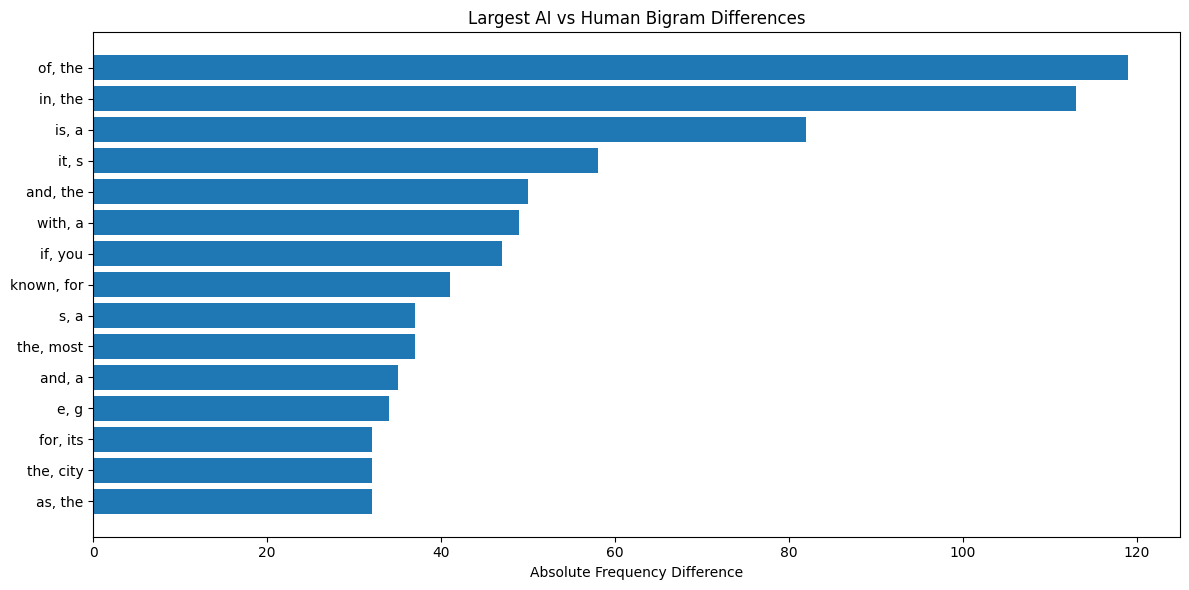

In [15]:
comparison = prepare_ngram_comparison(df_bigrams)

summary = get_summary(comparison)
top_ai = get_top_20_ai_bigrams(comparison)
top_human = get_top_20_human_bigrams(comparison)
largest_diff = get_largest_frequency_differences(comparison)

print(summary)
print(top_ai)
print(top_human)
print(largest_diff)

plot_largest_differences(comparison, save_path="bigram_differences.png")